## 03-2 선형 회귀

---

### k-최근접 이웃의 한계


In [ ]:
import numpy as np

perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    perch_length,
    perch_weight,
    random_state=42
)

train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

from sklearn.neighbors import KNeighborsRegressor

knr = KNeighborsRegressor(n_neighbors=3)
knr.fit(train_input, train_target)

# 길이가 50cm인 농어의 무게 예측
knr.predict([[50]]) # 1033.33g

array([1033.33333333])

길이가 50cm인 농어의 무게를 예측했을 때 1,033g이 나온다는게 말이되나? 이상하다...\
<br>
이를 위해 우리는 산점도를 그려서 확인해보자.

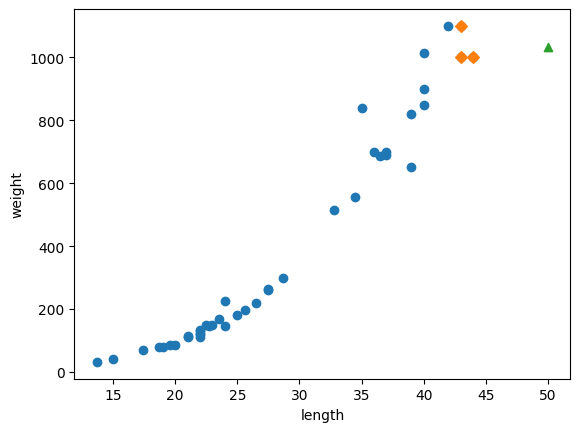

1033.3333333333333


In [15]:
import matplotlib.pyplot as plt

# 50cm 농어의 이웃을 구한다.
distances, indexes = knr.kneighbors([[50]])

plt.scatter(train_input, train_target)
plt.scatter(train_input[indexes], train_target[indexes], marker="D")
plt.scatter(50, 1033, marker="^")

plt.xlabel("length")
plt.ylabel("weight")

plt.show()

print(np.mean(train_target[indexes]))


새로운 샘플이 훈련 세트의 **범위를 벗어나게 되면서**, 엉뚱한 값을 예측한 것이다.\
따라서, 농어의 길이가 50cm이든 100cm든 여전히 1,033g으로 예측이 된다.
<br> 

&rArr; 이러한 문제의 해결하기 위해서는 가장 큰 농어가 포함되도록 훈련 세트를 다시 만들어야 한다...

#### 다른 방법은 없을까?

---

### 선형 회귀
이름에서 알 수 있듯이 어떤 직선을 학습하는 알고리즘이다.\
다만, 그 직선은 "그 특성"을 가장 잘 나타낼 수 있는 직신어야 한다.

<br>

사이킷런에 있는 `sklearn.linear_modle`패키지 아래의 `LinearRegression`클래스를 사용하면 된다.

In [17]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

# 모델 훈련
lr.fit(train_input, train_target)

# 예측
print(lr.predict([[50]]))

[1241.83860323]


확실이 k-최근접 이웃 회귀를 사용했을 때와 결과 예측이 다르게 나온다.\
<br>

> 왜 이런 결과가 나온걸까?

하나의 직선을 그리기 위해서는 **절편**과 **기울기**가 필요하다. &rArr; `y = a * x + b`
<br>

그러면 `LinearRegression`클래스가 알맞는 `a`와 `b`값을 찾았을 텐데,\
  어떻게 찾은거지?

In [ ]:
print(lr.coef_, lr.intercept_) # 기울기 y절편

[39.01714496] -709.0186449535474


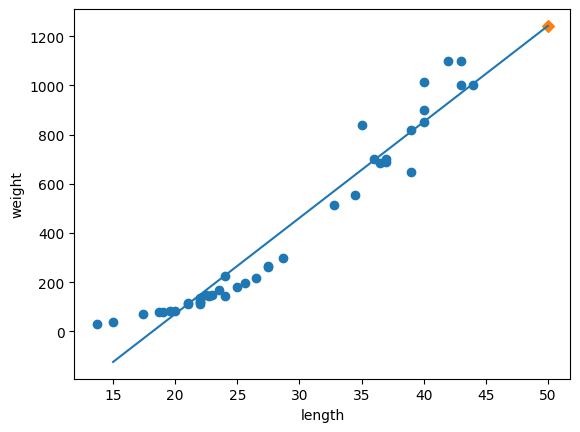

0.9398463339976041
0.824750312331356


In [22]:
plt.scatter(train_input, train_target)

# 농어의 길이 15에서 50까지 직선으로 그려본다. 1차 방정식
plt.plot([15, 50], [15 * lr.coef_ + lr.intercept_, 50 * lr.coef_ + lr.intercept_])

# 50cm 농어 데이터
plt.scatter(50, 1241.8, marker="D")

plt.xlabel("length")
plt.ylabel("weight")
plt.show()

print(lr.score(train_input, train_target))
print(lr.score(test_input, test_target))

훈련 세트의 점수보다 테스트 점수가 더 낮게 나오는 "과소적합"의 문제가 발생했다.

---

### 다항 회귀

우리가 그린 그래프대로 예측을 진행한다면, 농어의 무게가 0g 이하로 내려가게 될텐데...\
그런 일은 있을 수 없다.
<br>

그렇다면 "최적의 곡선"을 찾아보자\
&rArr; `w = a * l^2 + b * l + c`


In [ ]:
train_poly = np.column_stack((train_input ** 2, train_input))
test_poly = np.column_stack((test_input ** 2, test_input))

ex = np.hstack((train_input ** 2, train_input))
print(np.array_equal(ex, train_poly))

print(train_poly)
print(test_poly)

True


원래 특성인 길이를 제곱하여 왼쪽 열에 추가해 주었다.\
이를 바탕으로 다시 훈련시켜보자.

In [34]:
lr = LinearRegression()
lr.fit(train_poly, train_target)

print(lr.predict([[50**2, 50]]))
print(lr.coef_, lr.intercept_)

[1573.98423528]
[  1.01433211 -21.55792498] 116.0502107827827


따라서 이 모델은 다음과 같은 그래프를 학습한 것이다.\
&rArr; `w = 1.01 * l^2 - 21.6 * l + 116`

<br>  

이러한 방정식을 다항식이라고 부르며, 다항식을 이용한 선형 회귀를 **다항 회귀(polynomial regression)** 이라고 한다.\
그러면 해당 그래프를 그려보자.


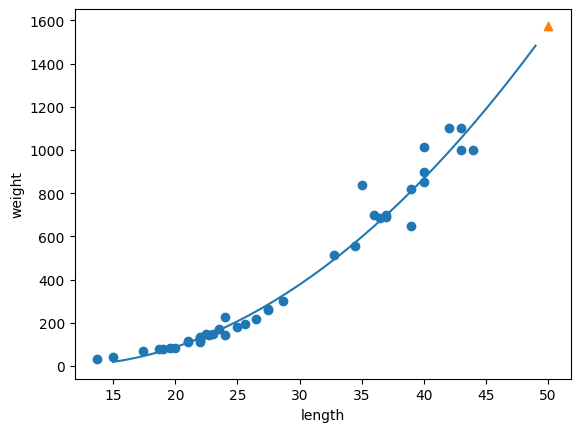

0.9706807451768623
0.9775935108325122


In [39]:
# 구간별 직선을 그리기 위해 15에서 49까지 정수 배열을 만든다.
point = np.arange(15, 50)

# 훈련 세트의 산점도를 그린다.
plt.scatter(train_input, train_target)

# 15에서 49까지 2차 방정식 그래프를 그린다.
plt.plot(point, 1.01 * point ** 2 - 21.6 * point + 116)

plt.scatter(50, 1574, marker="^")
plt.xlabel("length")
plt.ylabel("weight")
plt.show()

print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target))

훈련 세트와 테스트 세트에 대한 점수가 크게 좋아졌다.\
여전히 테스트 세트의 점수가 더 높은걸로 보아 과소적합이 남아있는 것 같으므로, 좀 더 복잡한 모델이 필요할 것으로 보인다.